# Amazon Video Games — Exploratory Data Analysis

目標：了解資料的基本樣貌，為後續 BERTopic 和預測模型的決策提供依據。

分析項目：
1. Rank 分佈（原始 vs log 轉換）
2. 評論數量隨時間趨勢
3. 星評分佈
4. Helpful Vote 分佈
5. 評論字數分佈
6. 驗證購買 vs 非驗證購買的差異
7. 各特徵與 log_rank 的相關性

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# 路徑設定
ROOT       = Path().resolve().parent
PROCESSED  = ROOT / 'data' / 'processed'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# 畫圖風格
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print('套件載入完成')

套件載入完成


In [14]:
# 讀取資料
meta    = pd.read_csv(PROCESSED / 'meta_clean.csv')
reviews = pd.read_csv(PROCESSED / 'reviews_clean.csv', parse_dates=['date'])
dataset = pd.read_csv(PROCESSED / 'dataset.csv', parse_dates=['date'])

print(f'商品數  : {len(meta):,}')
print(f'評論數  : {len(reviews):,}')
print(f'dataset : {len(dataset):,} 列 x {len(dataset.columns)} 欄')
dataset.head(3)

商品數  : 74,321
評論數  : 3,670,127
dataset : 3,670,127 列 x 16 欄


,parent_asin,user_id,rating,title,text,helpful_vote,verified_purchase,timestamp,date,text_length,rank,log_rank,price,average_rating,rating_number,store
0,B07DK1H3H5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,4.0,It’s pretty sexual. Not my fav,I’m playing on ps5 and it’s interesting. It’s...,0,True,1608186804795,2020-12-17 06:33:24.795,42,21854,9.992139,NaN,4.1,2015,WARNER BROS
1,B07SRWRH5D,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,5.0,Good. A bit slow,Nostalgic fun. A bit slow. I hope they don’t...,1,False,1587051114941,2020-04-16 15:31:54.941,17,1863,7.529943,25.95,4.8,9097,Square Enix
2,B07MFMFW34,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,5.0,... an order for my kids & they have really en...,This was an order for my kids & they have real...,0,True,1490877431000,2017-03-30 12:37:11.000,16,80256,11.292977,29.99,3.0,31,2K


## 1. Rank 分佈（原始 vs log 轉換）

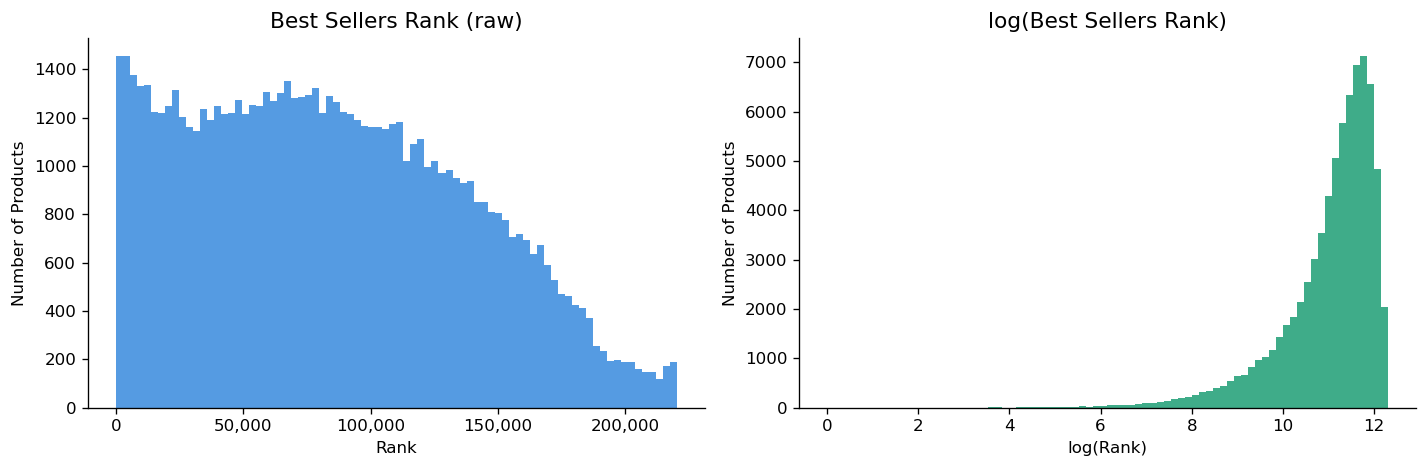

✅ 儲存：01_rank_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 原始 rank（商品層級）
axes[0].hist(meta['rank'], bins=80, color='#378ADD', edgecolor='none', alpha=0.85)
axes[0].set_title('Best Sellers Rank (raw)', fontsize=13)
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Number of Products')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# log_rank
axes[1].hist(meta['log_rank'], bins=80, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[1].set_title('log(Best Sellers Rank)', fontsize=13)
axes[1].set_xlabel('log(Rank)')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_rank_distribution.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：01_rank_distribution.png')

## 2. 評論數量隨時間趨勢

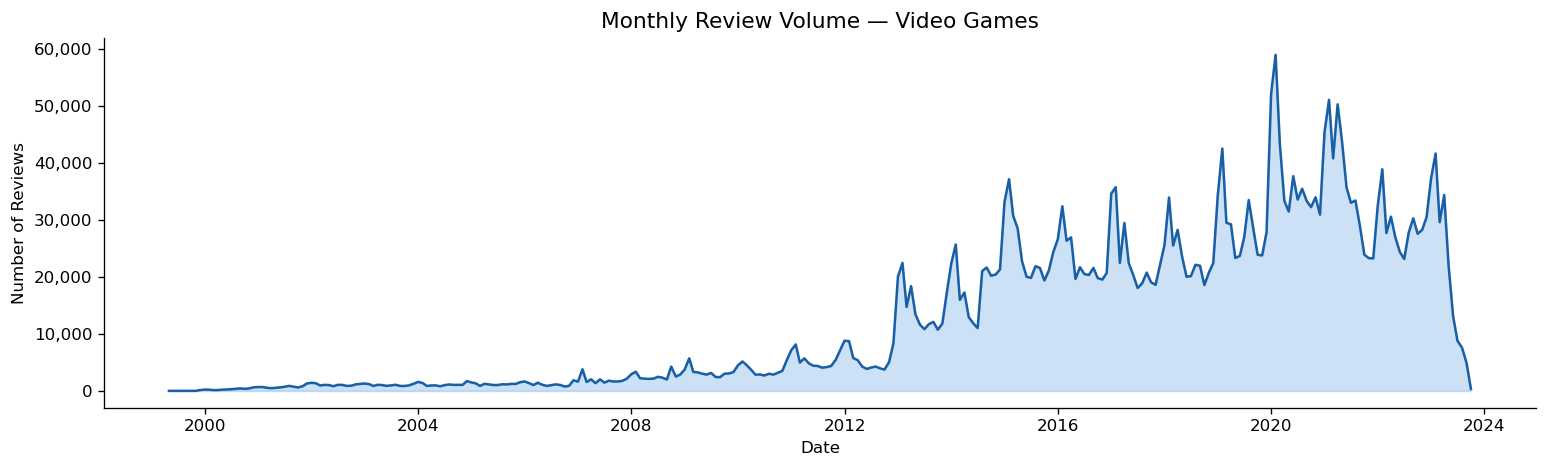

✅ 儲存：02_review_volume_over_time.png


In [5]:
# 按月統計評論數
monthly = (
    reviews.dropna(subset=['date'])
    .set_index('date')
    .resample('ME')
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly['date'], monthly['count'], alpha=0.25, color='#378ADD')
ax.plot(monthly['date'], monthly['count'], color='#185FA5', linewidth=1.5)
ax.set_title('Monthly Review Volume — Video Games', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_review_volume_over_time.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：02_review_volume_over_time.png')

## 3. 星評分佈

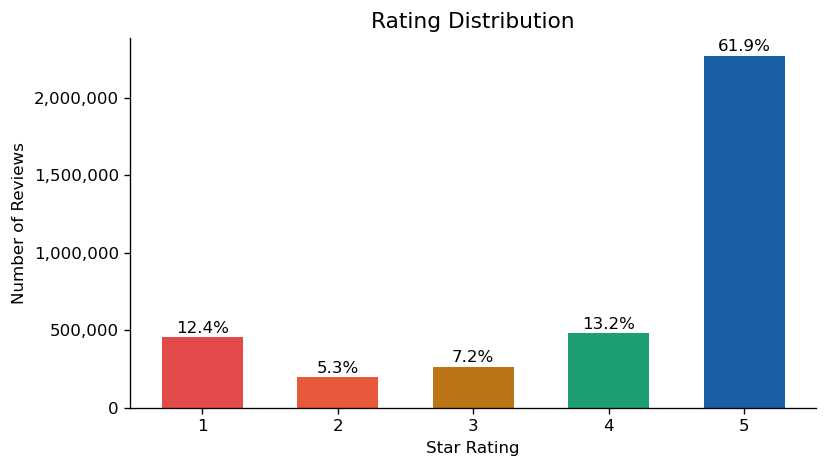

✅ 儲存：03_rating_distribution.png


In [6]:
rating_counts = reviews['rating'].value_counts().sort_index()
colors = ['#E24B4A', '#E8593C', '#BA7517', '#1D9E75', '#185FA5']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=colors, edgecolor='none', width=0.6)

# 加上百分比標籤
total = rating_counts.sum()
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
            f'{val/total*100:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Rating Distribution', fontsize=13)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_xticks([1, 2, 3, 4, 5])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_rating_distribution.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：03_rating_distribution.png')

## 4. Helpful Vote 分佈

Helpful Vote 基本統計：
count    3.670127e+06
mean     1.237524e+00
std      1.479804e+01
min     -1.000000e+00
50%      0.000000e+00
75%      1.000000e+00
90%      2.000000e+00
95%      4.000000e+00
99%      1.800000e+01
max      1.036900e+04

helpful_vote = 0 的比例：74.8%
helpful_vote >= 10 的比例：2.1%


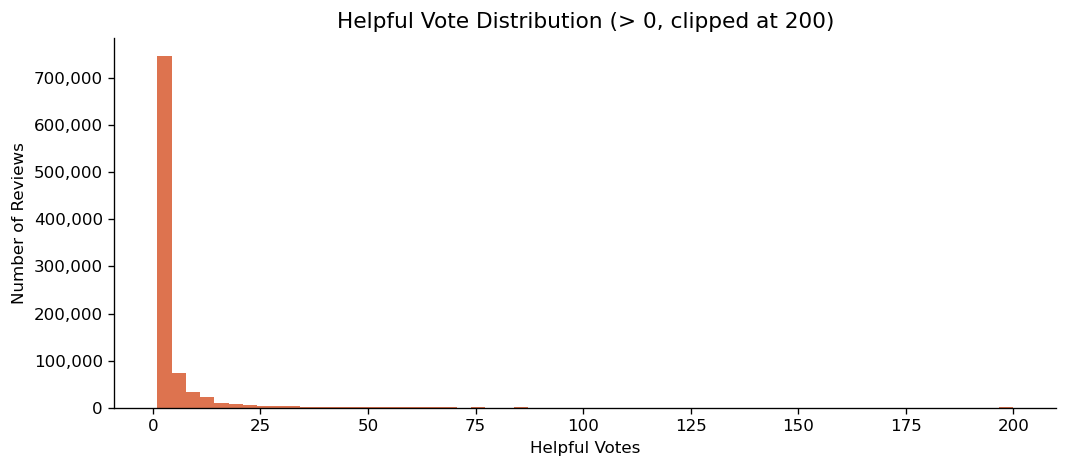

✅ 儲存：04_helpful_vote_distribution.png


In [7]:
hv = reviews['helpful_vote'].fillna(0)

print('Helpful Vote 基本統計：')
print(hv.describe(percentiles=[.5, .75, .90, .95, .99]).to_string())
print(f'\nhelpful_vote = 0 的比例：{(hv == 0).mean()*100:.1f}%')
print(f'helpful_vote >= 10 的比例：{(hv >= 10).mean()*100:.1f}%')

# 只畫有 helpful_vote 的（去掉 0）
hv_nonzero = hv[hv > 0].clip(upper=200)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(hv_nonzero, bins=60, color='#D85A30', edgecolor='none', alpha=0.85)
ax.set_title('Helpful Vote Distribution (> 0, clipped at 200)', fontsize=13)
ax.set_xlabel('Helpful Votes')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_helpful_vote_distribution.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：04_helpful_vote_distribution.png')

## 5. 評論字數分佈

評論字數基本統計：
count    3.670127e+06
mean     5.686157e+01
std      1.169600e+02
min      1.000000e+00
50%      2.400000e+01
75%      5.700000e+01
90%      1.290000e+02
95%      2.120000e+02
max      5.988000e+03


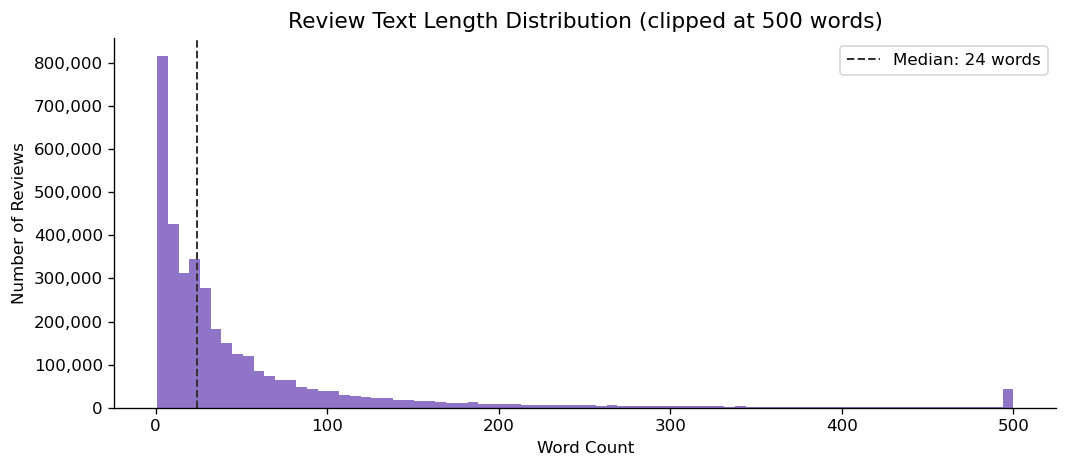

✅ 儲存：05_text_length_distribution.png


In [8]:
tl = reviews['text_length'].clip(upper=500)

print('評論字數基本統計：')
print(reviews['text_length'].describe(percentiles=[.5, .75, .90, .95]).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tl, bins=80, color='#7C5CBF', edgecolor='none', alpha=0.85)
ax.axvline(reviews['text_length'].median(), color='#333', linestyle='--',
           linewidth=1.2, label=f"Median: {reviews['text_length'].median():.0f} words")
ax.set_title('Review Text Length Distribution (clipped at 500 words)', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Reviews')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_text_length_distribution.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：05_text_length_distribution.png')

## 6. 驗證購買 vs 非驗證購買

驗證購買 vs 非驗證購買：
                     count  avg_rating  avg_helpful  avg_length
verified_purchase                                              
Unverified          516715    3.758064     3.267945  147.561176
Verified           3153412    4.118429     0.904822   41.999618


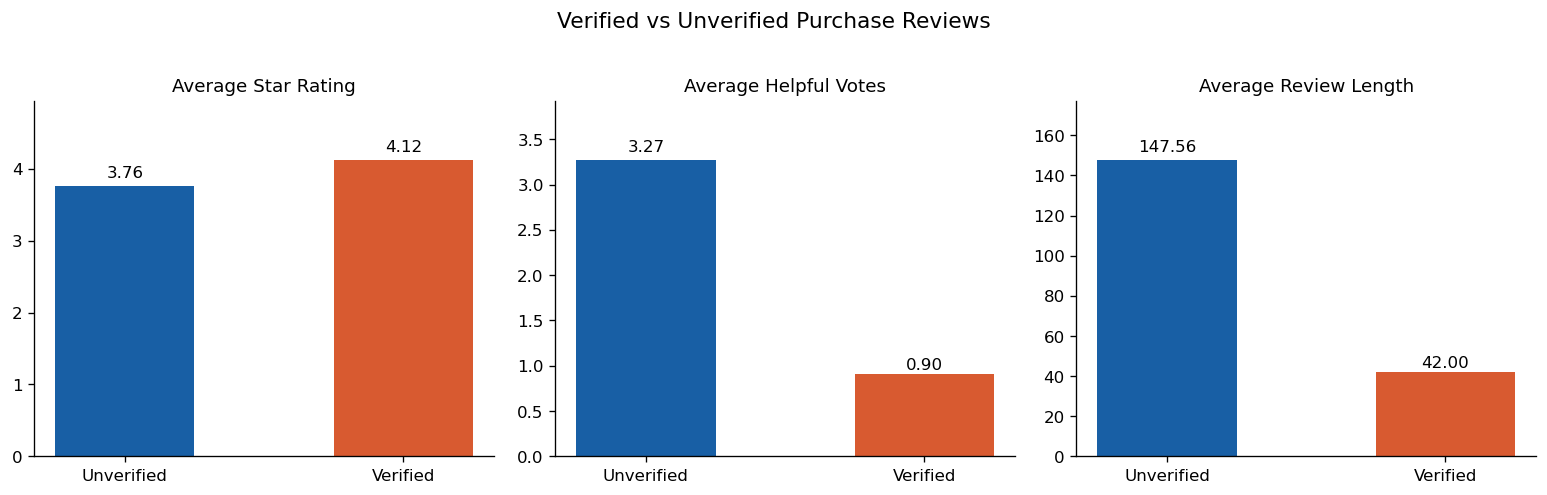

✅ 儲存：06_verified_vs_unverified.png


In [9]:
vp = reviews.groupby('verified_purchase').agg(
    count        = ('rating', 'count'),
    avg_rating   = ('rating', 'mean'),
    avg_helpful  = ('helpful_vote', 'mean'),
    avg_length   = ('text_length', 'mean')
).rename(index={True: 'Verified', False: 'Unverified'})

print('驗證購買 vs 非驗證購買：')
print(vp.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['avg_rating', 'avg_helpful', 'avg_length']
titles  = ['Average Star Rating', 'Average Helpful Votes', 'Average Review Length']
colors  = ['#185FA5', '#D85A30']

for ax, metric, title in zip(axes, metrics, titles):
    vals = vp[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='none', width=0.5)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, vals.max() * 1.2)

plt.suptitle('Verified vs Unverified Purchase Reviews', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_verified_vs_unverified.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：06_verified_vs_unverified.png')

## 7. 各特徵與 log_rank 的相關性

各特徵與 log_rank 的相關係數：
avg_rating         -0.292452
total_reviews      -0.265103
verified_ratio     -0.117173
rating_5_ratio     -0.111113
avg_helpful_vote    0.008016
price               0.039191
rating_1_ratio      0.048339
avg_text_length     0.080139


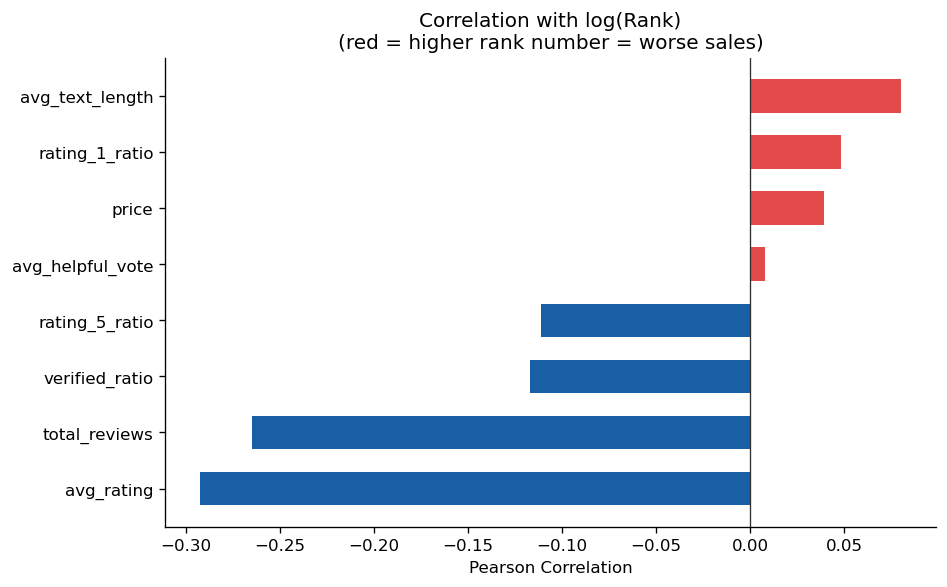

✅ 儲存：07_correlation_with_logrank.png


In [10]:
# 商品層級聚合（每個商品一列）
product_features = dataset.groupby('parent_asin').agg(
    log_rank          = ('log_rank', 'first'),
    price             = ('price', 'first'),
    avg_rating        = ('average_rating', 'first'),
    total_reviews     = ('rating', 'count'),
    avg_helpful_vote  = ('helpful_vote', 'mean'),
    avg_text_length   = ('text_length', 'mean'),
    verified_ratio    = ('verified_purchase', 'mean'),
    rating_1_ratio    = ('rating', lambda x: (x == 1).mean()),
    rating_5_ratio    = ('rating', lambda x: (x == 5).mean()),
).dropna(subset=['log_rank'])

# 相關係數
corr = product_features.corr()['log_rank'].drop('log_rank').sort_values()

print('各特徵與 log_rank 的相關係數：')
print(corr.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#E24B4A' if v > 0 else '#185FA5' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors_bar, edgecolor='none', height=0.6)
ax.axvline(0, color='#333', linewidth=0.8)
ax.set_title('Correlation with log(Rank)\n(red = higher rank number = worse sales)', fontsize=12)
ax.set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_correlation_with_logrank.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：07_correlation_with_logrank.png')

## EDA 摘要

跑完之後在這裡記錄重要發現，例如：
- log_rank 分佈是否接近常態
- 哪些特徵與 rank 的相關性最強
- helpful_vote 的門檻設多少合理（用於定義影響力評論者）
- 是否需要過濾異常值